In [3]:
!pip install -q datasets scikit-learn matplotlib seaborn pillow

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [5]:
from datasets import load_dataset

ds = load_dataset(
    "Project-AgML/fresh_rotten_fruit_classification",
    "raw"
)

print(ds)

README.md:   0%|          | 0.00/2.05k [00:00<?, ?B/s]

raw/train-00000-of-00004.parquet: reconstructing file:   0%|          |  0.00B /  324MB            

raw/train-00000-of-00004.parquet: downloading bytes:           |  0.00B            

raw/train-00001-of-00004.parquet: reconstructing file:   0%|          |  0.00B /  964MB            

raw/train-00001-of-00004.parquet: downloading bytes:           |  0.00B            

...

raw/train-00002-of-00004.parquet: downloading bytes:           |  0.00B            

raw/train-00003-of-00004.parquet: reconstructing file:   0%|          |  0.00B /  913MB            

raw/train-00003-of-00004.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/3200 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'fruit_type'],
        num_rows: 3200
    })
})


In [6]:
print(ds["train"].features["label"].names)

['fresh', 'rotten']


In [7]:
from collections import Counter

labels = ds["train"]["label"]

print(Counter(labels))

for label_id, count in Counter(labels).items():
    label_name = ds["train"].features["label"].names[label_id]
    print(f"{label_name}: {count}")

Counter({0: 1600, 1: 1600})
fresh: 1600
rotten: 1600


In [8]:
print(ds["train"].features["fruit_type"].names)

AttributeError: 'Value' object has no attribute 'names'

In [9]:
print(ds["train"].features)

{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['fresh', 'rotten']), 'fruit_type': Value('string')}


In [10]:
print("Label values:", sorted(set(ds["train"]["label"])))

Label values: [0, 1]


In [11]:
from collections import Counter

label_counts = Counter(ds["train"]["label"])

print("Label distribution:")

for label, count in sorted(label_counts.items()):
    print(f"Label {label}: {count}")

Label distribution:
Label 0: 1600
Label 1: 1600


In [12]:
fruit_types = ds["train"]["fruit_type"]

print("Fruit types:")
print(sorted(set(fruit_types)))

Fruit types:
['apple', 'banana', 'grape', 'guava', 'jujube', 'orange', 'pomegranate', 'strawberry']


In [13]:
print(ds["train"].features["label"])

ClassLabel(names=['fresh', 'rotten'])


{'image': <PIL.Image.Image image mode=RGB size=4160x3120 at 0x7C80B7589010>, 'label': 0, 'fruit_type': 'apple'}


In [ ]:
from collections import Counter

label_counts = Counter(ds["train"]["label"])

print("Label distribution:")

for label, count in sorted(label_counts.items()):
    print(f"Label {label}: {count}")

Label distribution:
Label 0: 1600
Label 1: 1600


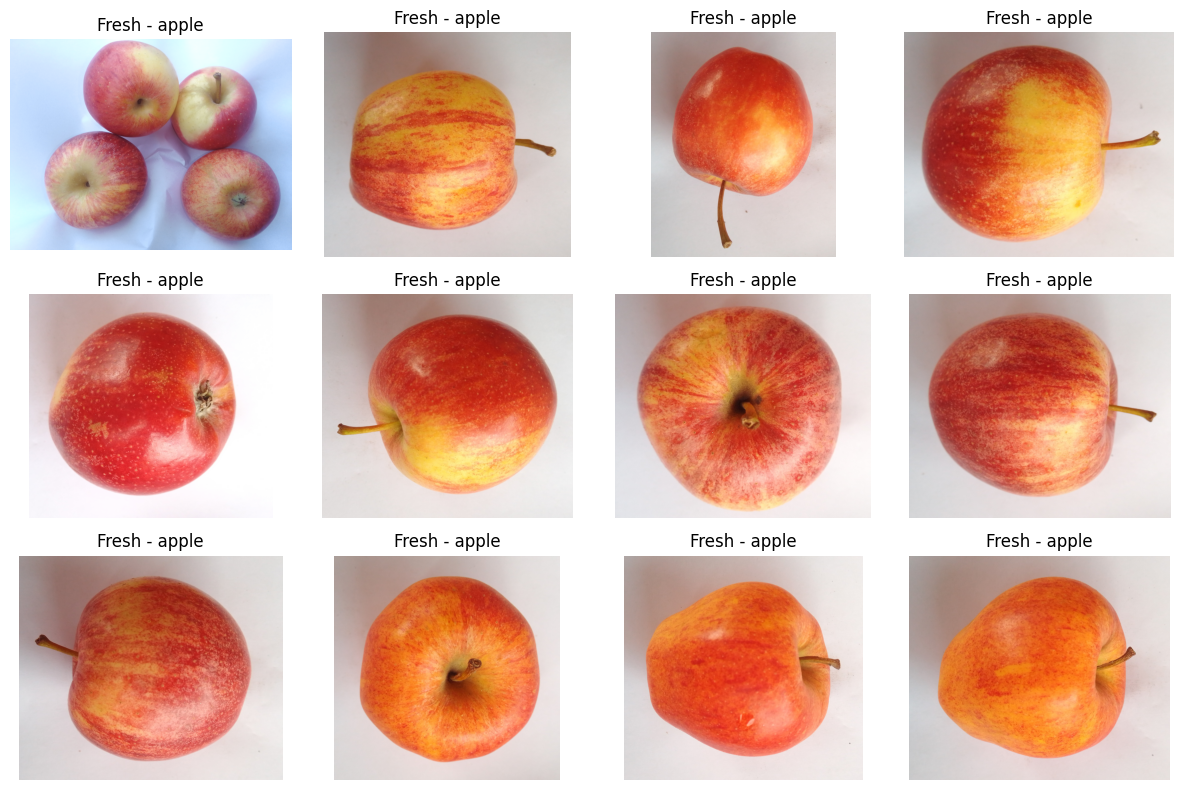

In [16]:
plt.figure(figsize=(12, 8))

for i in range(12):

    sample = ds["train"][i]

    image = sample["image"]
    label = sample["label"]

    label_name = "Fresh" if label == 0 else "Rotten"

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)
    plt.title(
        f"{label_name} - {sample['fruit_type']}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
from sklearn.model_selection import train_test_split
import numpy as np

# Get all dataset indices
indices = np.arange(len(ds["train"]))

# Get labels for stratified splitting
labels = np.array(ds["train"]["label"])

# 70% training, 30% temporary
train_indices, temp_indices = train_test_split(
    indices,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

# Split the remaining 30% into
# 15% validation and 15% test
temp_labels = labels[temp_indices]

val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print("Training images:", len(train_indices))
print("Validation images:", len(val_indices))
print("Testing images:", len(test_indices))

Training images: 2240
Validation images: 480
Testing images: 480


In [19]:
IMG_SIZE = 128
BATCH_SIZE = 32

def preprocess_image(image, label):
    # Convert PIL image to TensorFlow tensor
    image = tf.convert_to_tensor(
        np.array(image),
        dtype=tf.float32
    )

    # Resize image
    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )

    # Normalize pixel values from 0-255 to 0-1
    image = image / 255.0

    return image, label

In [21]:
def create_tf_dataset(indices, shuffle=False):

    images = []
    labels_list = []

    for index in indices:
        sample = ds["train"][int(index)]

        images.append(
            np.array(
                sample["image"].convert("RGB")
            )
        )

        labels_list.append(
            sample["label"]
        )

    dataset = tf.data.Dataset.from_tensor_slices(
        (images, labels_list)
    )

    dataset = dataset.map(
        preprocess_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=1000,
            seed=42
        )

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset

In [1]:
train_ds = create_tf_dataset(
    train_indices,
    shuffle=True
)

val_ds = create_tf_dataset(
    val_indices
)

test_ds = create_tf_dataset(
    test_indices
)

print("TensorFlow datasets created successfully!")

NameError: name 'create_tf_dataset' is not defined

In [2]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from datasets import load_dataset

ds = load_dataset(
    "Project-AgML/fresh_rotten_fruit_classification",
    "raw"
)

print(ds)

DatasetDict({
    train: Dataset({
        features: ['image', 'label', 'fruit_type'],
        num_rows: 3200
    })
})


In [4]:
import numpy as np
from sklearn.model_selection import train_test_split

# Create indices for all 3200 images
indices = np.arange(len(ds["train"]))

# Get labels
labels = np.array(ds["train"]["label"])

# 70% training, 30% temporary
train_indices, temp_indices = train_test_split(
    indices,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

# Split temporary data into 15% validation and 15% test
val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.50,
    random_state=42,
    stratify=labels[temp_indices]
)

print("Training images:", len(train_indices))
print("Validation images:", len(val_indices))
print("Testing images:", len(test_indices))

Training images: 2240
Validation images: 480
Testing images: 480


In [6]:
IMG_SIZE = 128
BATCH_SIZE = 32

def image_generator(indices):
    for index in indices:
        sample = ds["train"][int(index)]

        image = np.array(
            sample["image"].convert("RGB"),
            dtype=np.uint8
        )

        label = np.float32(sample["label"])

        yield image, label

In [7]:
import tensorflow as tf

output_signature = (
    tf.TensorSpec(
        shape=(None, None, 3),
        dtype=tf.uint8
    ),
    tf.TensorSpec(
        shape=(),
        dtype=tf.float32
    )
)

train_ds = tf.data.Dataset.from_generator(
    lambda: image_generator(train_indices),
    output_signature=output_signature
)

val_ds = tf.data.Dataset.from_generator(
    lambda: image_generator(val_indices),
    output_signature=output_signature
)

test_ds = tf.data.Dataset.from_generator(
    lambda: image_generator(test_indices),
    output_signature=output_signature
)

In [8]:
def preprocess(image, label):

    image = tf.image.resize(
        image,
        (IMG_SIZE, IMG_SIZE)
    )

    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    return image, label

In [9]:
train_ds = train_ds.map(
    preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = val_ds.map(
    preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = test_ds.map(
    preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [10]:
for images, labels_batch in train_ds.take(1):

    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels_batch.shape)
    print("Pixel minimum:", tf.reduce_min(images).numpy())
    print("Pixel maximum:", tf.reduce_max(images).numpy())

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
Pixel minimum: 0.0
Pixel maximum: 1.0


In [11]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip(
        "horizontal"
    ),

    tf.keras.layers.RandomRotation(
        0.15
    ),

    tf.keras.layers.RandomZoom(
        0.15
    ),

    tf.keras.layers.RandomContrast(
        0.10
    )
])

print("Data augmentation created successfully.")

Data augmentation created successfully.


In [12]:
model = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=(128, 128, 3)
    ),

    # =========================
    # DATA AUGMENTATION
    # =========================

    data_augmentation,

    # =========================
    # CNN BLOCK 1
    # =========================

    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # =========================
    # CNN BLOCK 2
    # =========================

    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # =========================
    # CNN BLOCK 3
    # =========================

    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # =========================
    # CNN BLOCK 4
    # =========================

    tf.keras.layers.Conv2D(
        256,
        (3, 3),
        activation="relu",
        padding="same"
    ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.MaxPooling2D(
        (2, 2)
    ),

    # =========================
    # CLASSIFIER
    # =========================

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        256,
        activation="relu"
    ),

    tf.keras.layers.Dropout(
        0.5
    ),

    # =========================
    # BINARY OUTPUT
    # =========================

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

In [13]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,585,153 (17.49 MB)

 Trainable params: 4,584,193 (17.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        )
    ]
)

print("Model compiled successfully.")

Model compiled successfully.


In [15]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=2,
        min_lr=1e-6
    )
]

print("Callbacks created successfully.")

Callbacks created successfully.


In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
     70/Unknown 159s 2s/step - accuracy: 0.7283 - loss: 2.1201 - precision: 0.7212 - recall: 0.7266

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


70/70 ━━━━━━━━━━━━━━━━━━━━ 194s 3s/step - accuracy: 0.7705 - loss: 1.4619 - precision: 0.7681 - recall: 0.7750 - val_accuracy: 0.5083 - val_loss: 2.0681 - val_precision: 0.5042 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.8299 - loss: 0.4810 - precision: 0.8267 - recall: 0.8348 - val_accuracy: 0.8000 - val_loss: 0.4889 - val_precision: 0.7927 - val_recall: 0.8125 - learning_rate: 0.0010
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 179s 3s/step - accuracy: 0.8540 - loss: 0.3652 - precision: 0.8556 - recall: 0.8518 - val_accuracy: 0.6917 - val_loss: 0.6477 - val_precision: 0.8239 - val_recall: 0.4875 - learning_rate: 0.0010
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.8594 - loss: 0.3866 - precision: 0.8491 - recall: 0.8741 - val_accuracy: 0.6812 - val_loss: 0.6404 - val_precision: 0.6445 - val_recall: 0.8083 - learning_rate: 0.0010
Epoch 5/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.8826 - loss: 0

In [17]:
print("Best Training Accuracy:",
      max(history.history["accuracy"]) * 100)

print("Best Validation Accuracy:",
      max(history.history["val_accuracy"]) * 100)

print("Training Epochs:",
      len(history.history["loss"]))

Best Training Accuracy: 97.1875011920929
Best Validation Accuracy: 97.29166626930237
Training Epochs: 28


In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

NameError: name 'plt' is not defined

In [19]:
import matplotlib.pyplot as plt

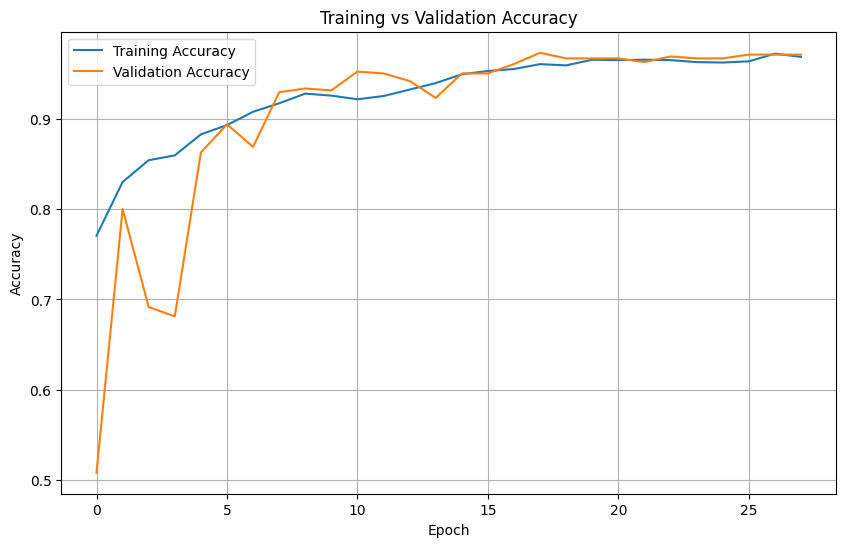

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

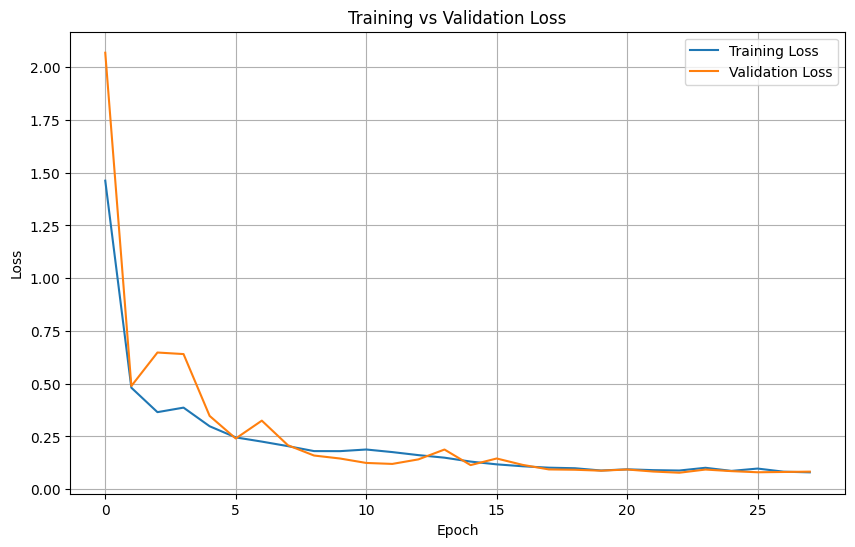

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [22]:
test_results = model.evaluate(
    test_ds,
    verbose=1
)

print("\n===== TEST RESULTS =====")
print(f"Loss:      {test_results[0]:.4f}")
print(f"Accuracy:  {test_results[1]:.4f}")
print(f"Precision: {test_results[2]:.4f}")
print(f"Recall:    {test_results[3]:.4f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.9521 - loss: 0.1135 - precision: 0.9657 - recall: 0.9375

===== TEST RESULTS =====
Loss:      0.1135
Accuracy:  0.9521
Precision: 0.9657
Recall:    0.9375


In [23]:
y_true = []
y_pred = []

for images, labels_batch in test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    y_true.extend(
        labels_batch.numpy().astype(int)
    )

    y_pred.extend(
        (predictions >= 0.5).astype(int).flatten()
    )

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated:", len(y_pred))

Predictions generated: 480


In [24]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Fresh", "Rotten"],
        digits=4
    )
)

              precision    recall  f1-score   support

       Fresh     0.9393    0.9667    0.9528       240
      Rotten     0.9657    0.9375    0.9514       240

    accuracy                         0.9521       480
   macro avg     0.9525    0.9521    0.9521       480
weighted avg     0.9525    0.9521    0.9521       480



In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fresh", "Rotten"],
    yticklabels=["Fresh", "Rotten"]
)

plt.title("Fresh vs Rotten Fruit Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

NameError: name 'sns' is not defined

<Figure size 700x600 with 0 Axes>

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

Confusion Matrix:
[[232   8]
 [ 15 225]]


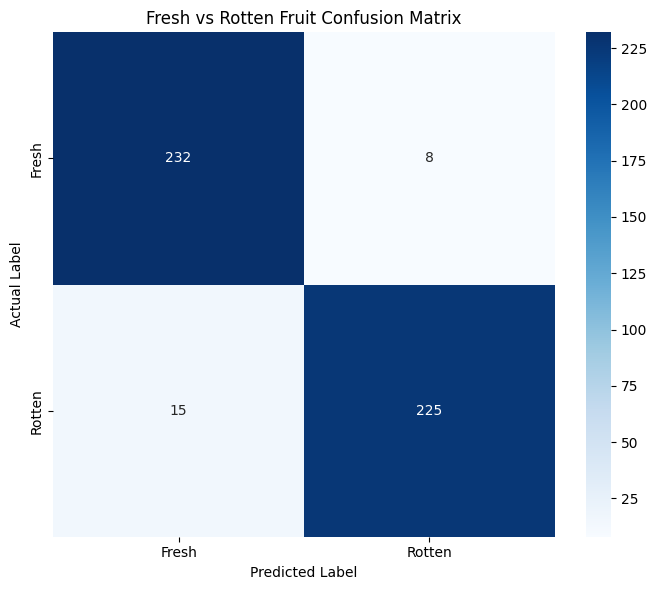

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fresh", "Rotten"],
    yticklabels=["Fresh", "Rotten"]
)

plt.title("Fresh vs Rotten Fruit Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

In [28]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=["Fresh", "Rotten"],
    digits=4
)

print(report)

              precision    recall  f1-score   support

       Fresh     0.9393    0.9667    0.9528       240
      Rotten     0.9657    0.9375    0.9514       240

    accuracy                         0.9521       480
   macro avg     0.9525    0.9521    0.9521       480
weighted avg     0.9525    0.9521    0.9521       480



In [29]:
from sklearn.metrics import f1_score

f1 = f1_score(
    y_true,
    y_pred
)

print(f"F1 Score: {f1 * 100:.2f}%")

F1 Score: 95.14%


In [ ]:
print("Confusion Matrix:")
print(cm)

print("\nInterpretation:")
print("Actual Fresh → Predicted Fresh:", cm[0][0])
print("Actual Fresh → Predicted Rotten:", cm[0][1])
print("Actual Rotten → Predicted Fresh:", cm[1][0])
print("Actual Rotten → Predicted Rotten:", cm[1][1])

Confusion Matrix:
[[232   8]
 [ 15 225]]

Interpretation:
Actual Fresh → Predicted Fresh: 232
Actual Fresh → Predicted Rotten: 8
Actual Rotten → Predicted Fresh: 15
Actual Rotten → Predicted Rotten: 225


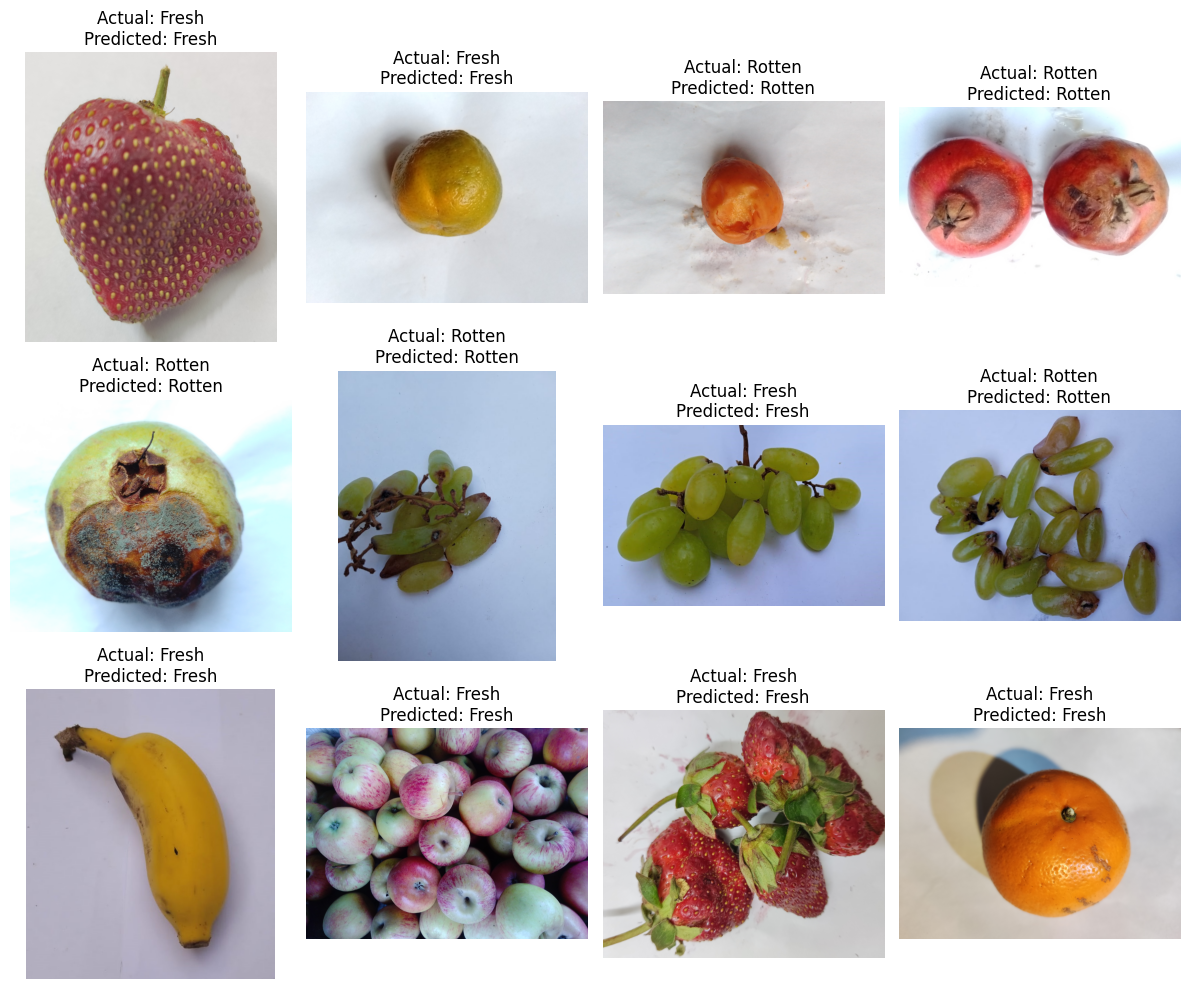

In [32]:
import matplotlib.pyplot as plt
import numpy as np

class_names = ["Fresh", "Rotten"]

# Get 12 test samples
sample_indices = test_indices[:12]

plt.figure(figsize=(12, 10))

for i, index in enumerate(sample_indices):

    sample = ds["train"][int(index)]

    # Original image
    image = sample["image"].convert("RGB")

    # Resize exactly like the model input
    image_array = np.array(image, dtype=np.float32)

    resized = tf.image.resize(
        image_array,
        (128, 128)
    )

    resized = resized / 255.0

    # Add batch dimension
    input_image = tf.expand_dims(
        resized,
        axis=0
    )

    # Prediction
    probability = model.predict(
        input_image,
        verbose=0
    )[0][0]

    predicted_label = 1 if probability >= 0.5 else 0

    actual_label = int(sample["label"])

    actual_name = class_names[actual_label]
    predicted_name = class_names[predicted_label]

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    plt.title(
        f"Actual: {actual_name}\n"
        f"Predicted: {predicted_name}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [33]:
model.save(
    "fresh_rotten_fruit_cnn.keras"
)

print("Model saved successfully!")

Model saved successfully!


In [34]:
import os

os.makedirs("outputs", exist_ok=True)

print("Output folder created.")

Output folder created.


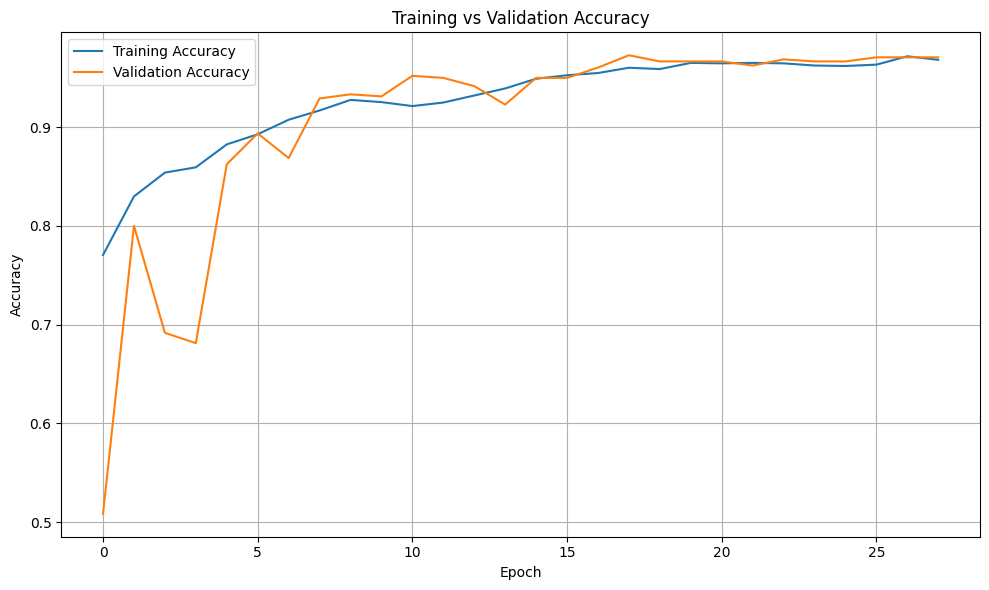

Saved: outputs/accuracy_curve.png


In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "outputs/accuracy_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: outputs/accuracy_curve.png")

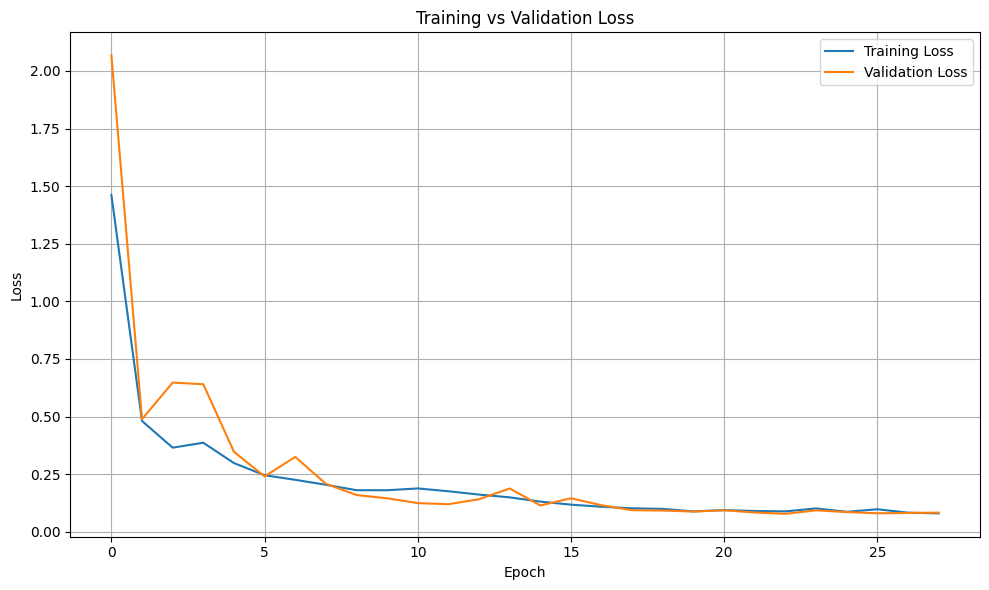

Saved: outputs/loss_curve.png


In [36]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "outputs/loss_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: outputs/loss_curve.png")

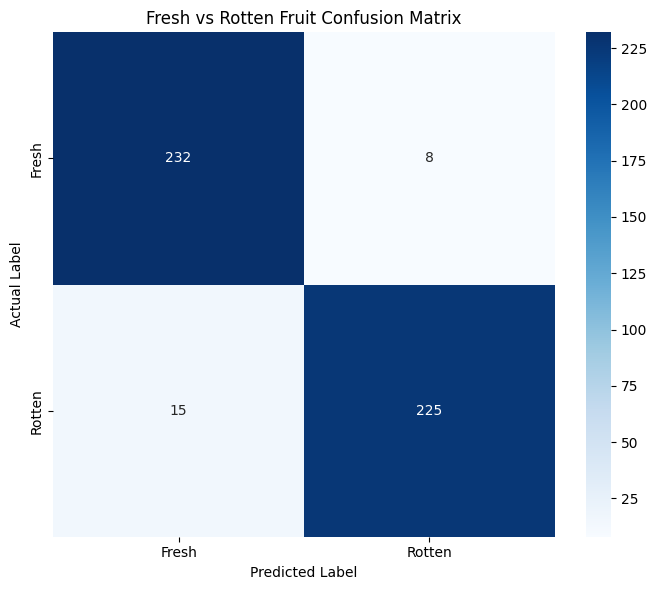

Saved: outputs/confusion_matrix.png


In [37]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fresh", "Rotten"],
    yticklabels=["Fresh", "Rotten"]
)

plt.title("Fresh vs Rotten Fruit Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()

plt.savefig(
    "outputs/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved: outputs/confusion_matrix.png")

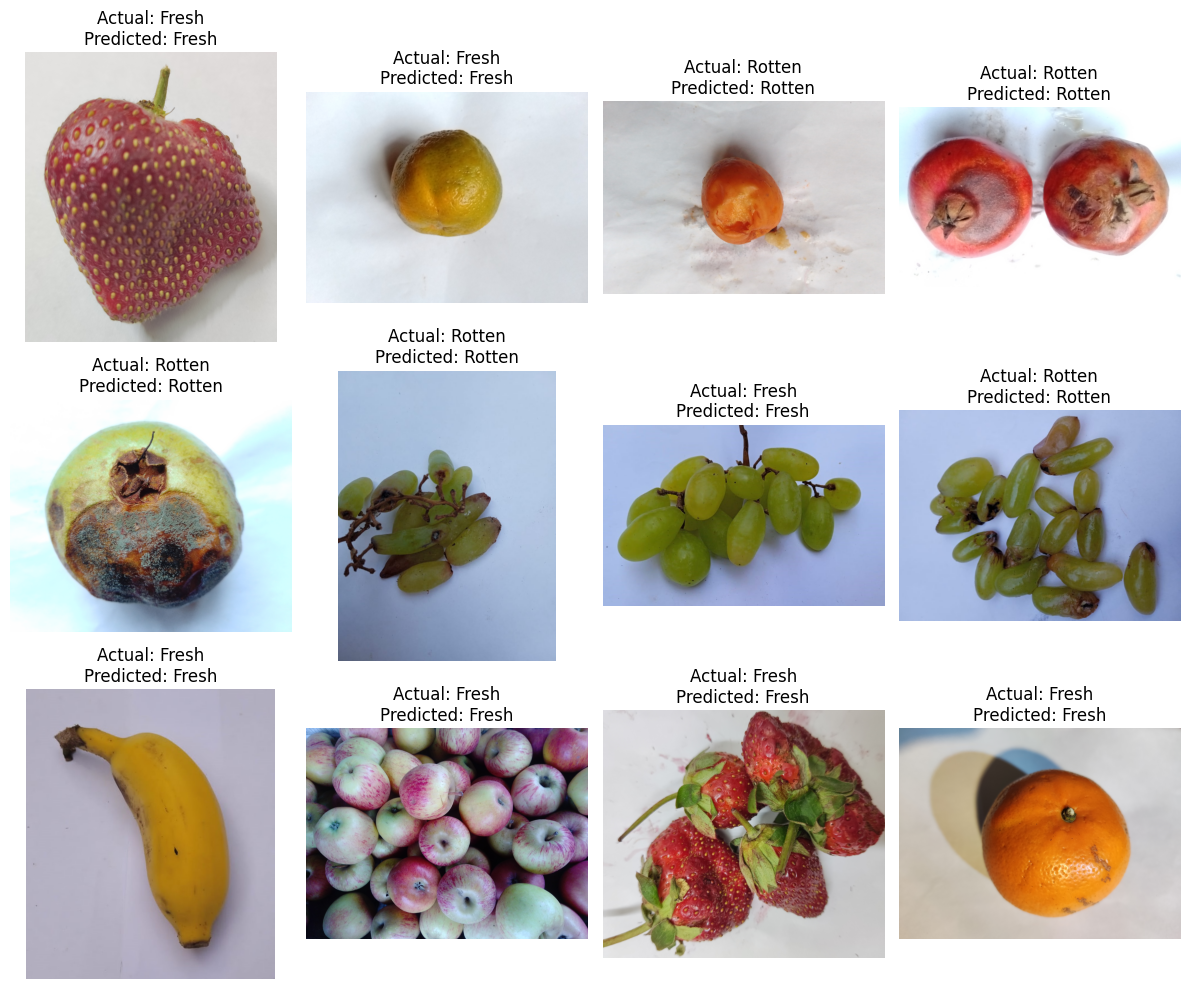

Saved: outputs/sample_predictions.png


In [38]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

class_names = ["Fresh", "Rotten"]

sample_indices = test_indices[:12]

plt.figure(figsize=(12, 10))

for i, index in enumerate(sample_indices):

    sample = ds["train"][int(index)]

    # Original image
    image = sample["image"].convert("RGB")

    # Convert to NumPy
    image_array = np.array(
        image,
        dtype=np.float32
    )

    # Resize for CNN
    resized = tf.image.resize(
        image_array,
        (128, 128)
    )

    # Normalize
    resized = resized / 255.0

    # Add batch dimension
    input_image = tf.expand_dims(
        resized,
        axis=0
    )

    # CNN prediction
    probability = model.predict(
        input_image,
        verbose=0
    )[0][0]

    predicted_label = (
        1 if probability >= 0.5 else 0
    )

    actual_label = int(
        sample["label"]
    )

    actual_name = class_names[
        actual_label
    ]

    predicted_name = class_names[
        predicted_label
    ]

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    plt.title(
        f"Actual: {actual_name}\n"
        f"Predicted: {predicted_name}"
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "outputs/sample_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved: outputs/sample_predictions.png"
)

In [39]:
model.save(
    "fresh_rotten_fruit_cnn.keras"
)

print("Model saved successfully!")

Model saved successfully!


In [40]:
import os

print("Project files:")

for root, dirs, files in os.walk("."):
    for file in files:

        if (
            file.endswith(".png")
            or file.endswith(".keras")
        ):
            print(
                os.path.join(root, file)
            )

Project files:
./fresh_rotten_fruit_cnn.keras
./outputs/loss_curve.png
./outputs/sample_predictions.png
./outputs/accuracy_curve.png
./outputs/confusion_matrix.png


In [41]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Fresh", "Rotten"],
        digits=4
    )
)

              precision    recall  f1-score   support

       Fresh     0.9393    0.9667    0.9528       240
      Rotten     0.9657    0.9375    0.9514       240

    accuracy                         0.9521       480
   macro avg     0.9525    0.9521    0.9521       480
weighted avg     0.9525    0.9521    0.9521       480



In [42]:
requirements = """tensorflow>=2.19
numpy
matplotlib
seaborn
scikit-learn
datasets
Pillow
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("requirements.txt created!")

requirements.txt created!
